In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
GREEN = (0, 255, 0)
RED = (255, 0, 0)

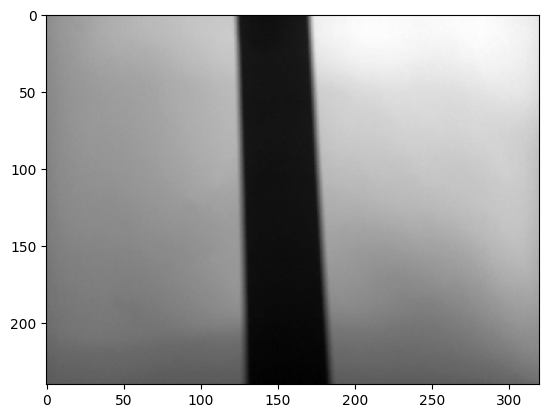

In [10]:
image = cv2.imread('line_1.jpg')
resized = cv2.resize(image, (320, 240))
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')


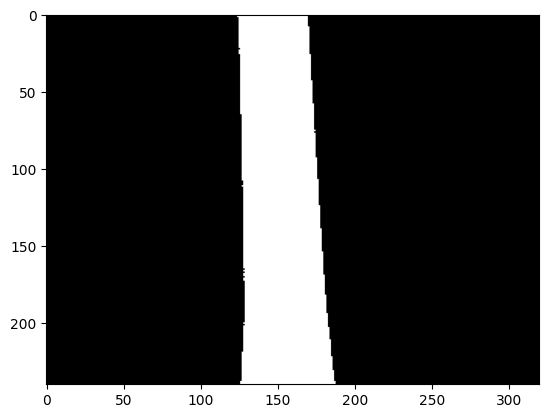

In [11]:
masked = cv2.inRange(gray, 0, 50)
plt.imshow(masked, cmap='gray')

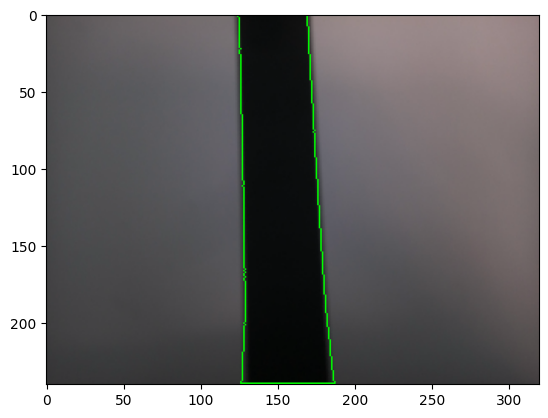

In [12]:
contours, _ = cv2.findContours(masked, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
cv2.drawContours(resized, [largest_contour], -1, GREEN, 1)
plt.imshow(resized)

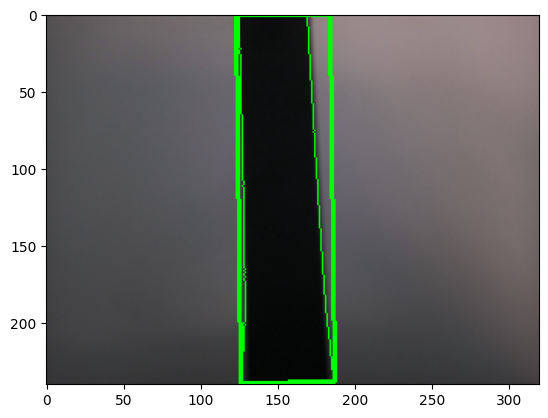

In [13]:
rect = cv2.minAreaRect(largest_contour)
box = cv2.boxPoints(rect)
box = np.intp(box)
cv2.drawContours(resized, [box], 0, GREEN, 2)
plt.imshow(resized)

In [14]:
((center_x, center_y)), (width, height), theta = rect

if width < height:
    theta += 90.0
    length = height
else:
    length = width

theta = theta + 180
int(theta), int(length)

(269, 239)

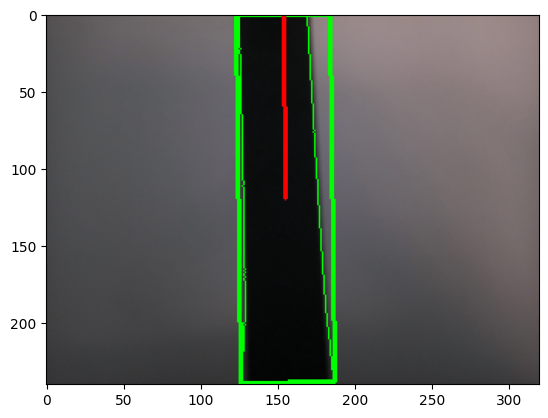

In [15]:
theta = np.deg2rad(theta)
end = (
    int(center_x + length/2 * np.cos(theta)), 
    int(center_y + length/2 * np.sin(theta))
)
cv2.line(resized, (int(center_x), int(center_y)), end, RED, 2)
plt.imshow(resized)

In [16]:
images_to_test = [
    "line_1.jpg",
    "line_2.jpg",
    "line_3.jpg",
    "line_4.jpg",
    "line_5.jpg",
    "line_6.jpg",
    "carpet_line1.jpg",
    "empty_carpet.jpg",
    "empty_gray.jpg"
]

In [ ]:
def test_image(resized):                
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        masked = cv2.inRange(gray, 0, 50)
        contours, _ = cv2.findContours(masked, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            print("No contours found")
            return None

        largest_contour = max(contours, key=cv2.contourArea)
        rect = cv2.minAreaRect(largest_contour)
        box = cv2.boxPoints(rect)
        box = np.intp(box)
        cv2.drawContours(resized, [box], 0, GREEN, 2)

        ((center_x, center_y)), (width, height), theta = rect
        if min(width, height) < 10:
            print("Detected line is too small")
            return None

        if width < height:
            theta += 90.0
            length = height
        else:
            length = width

        theta = theta + 180

        theta = np.deg2rad(theta)
        end = (
            int(center_x + length/2 * np.cos(theta)), 
            int(center_y + length/2 * np.sin(theta))
        )
        cv2.line(resized, (int(center_x), int(center_y)), end, RED, 2)
        plt.imshow(resized)

Testing image line_1.jpg
Testing image line_2.jpg
Testing image line_3.jpg
Testing image line_4.jpg
Testing image line_5.jpg
Testing image line_6.jpg
Testing image carpet_line1.jpg
Testing image empty_carpet.jpg
No contours found
Testing image empty_gray.jpg
Detected line is too small


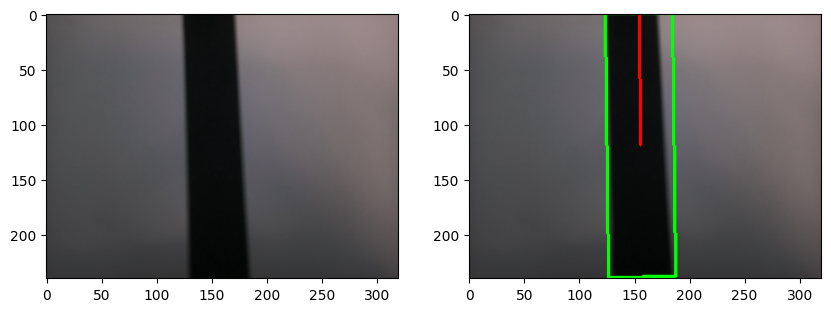

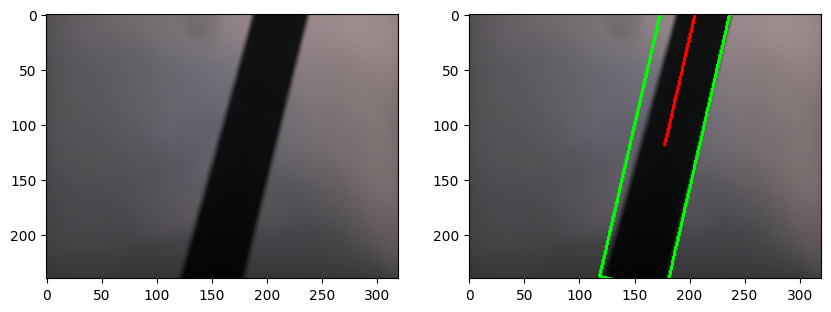

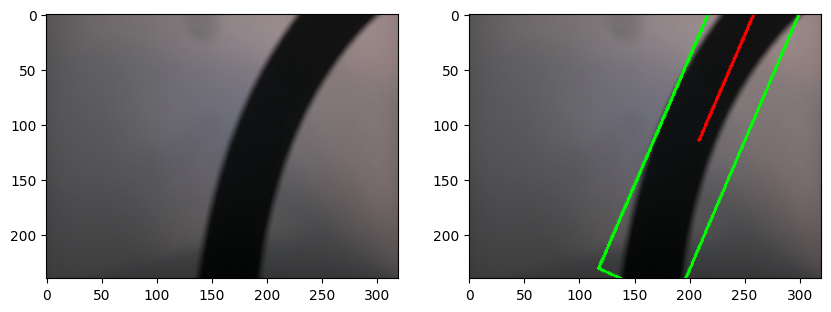

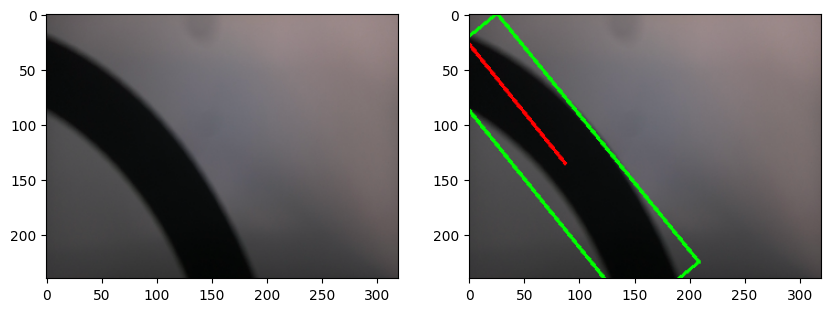

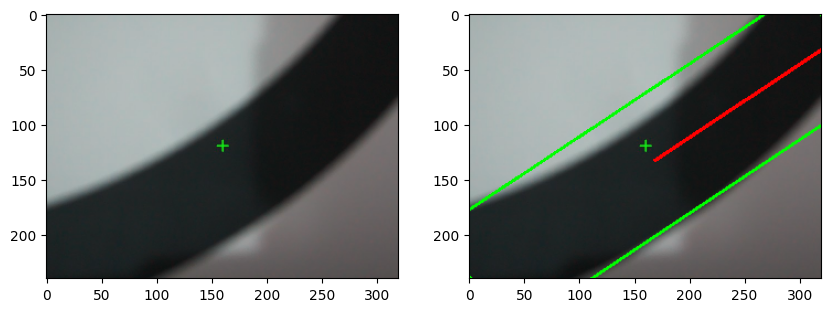

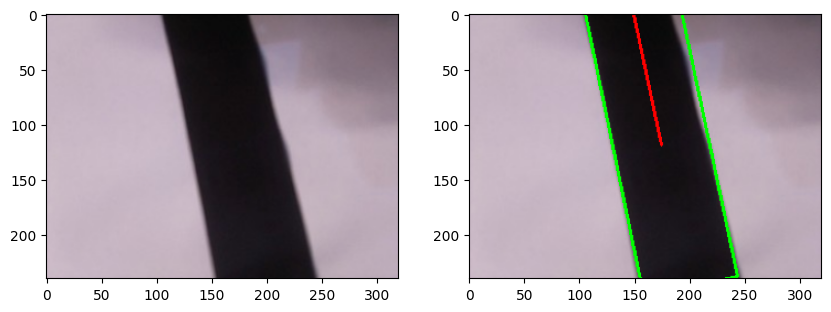

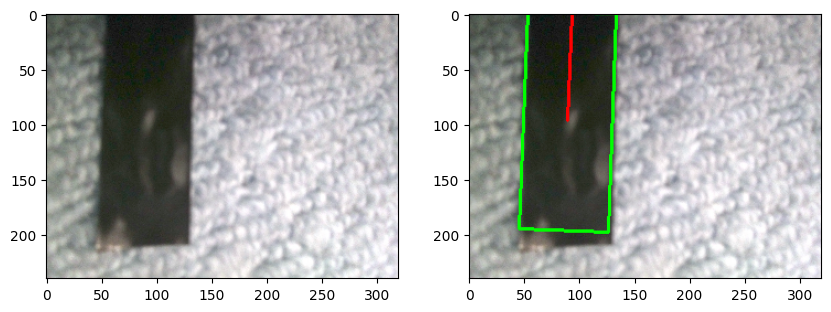

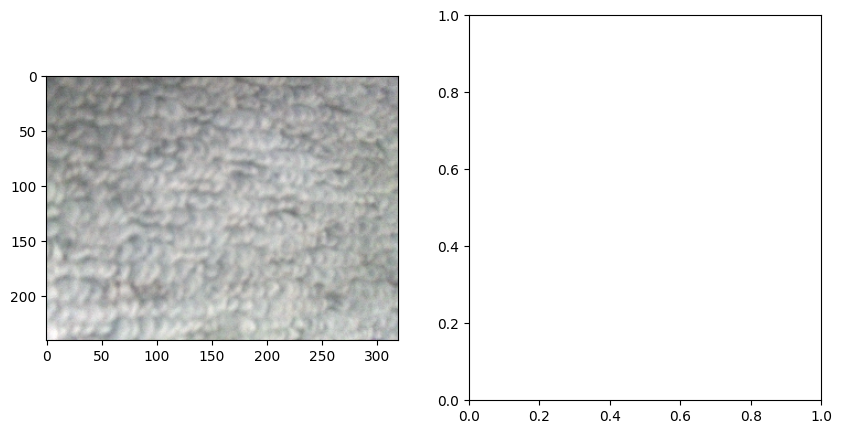

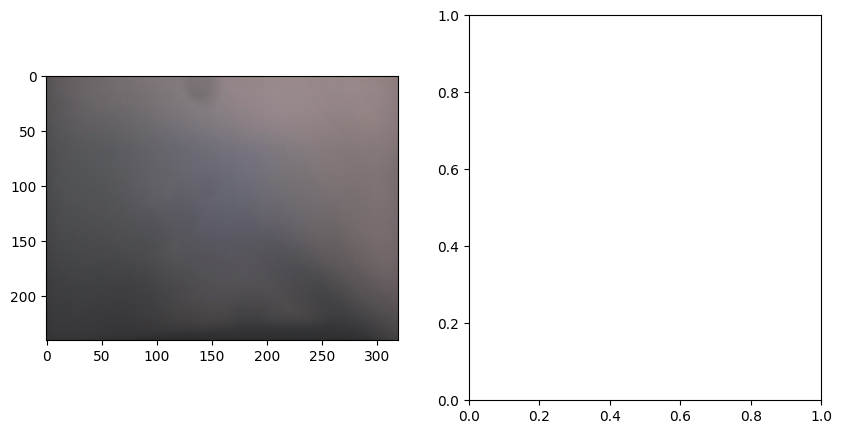

In [19]:
for image_name in images_to_test:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    print(f"Testing image {image_name}")
    image = cv2.imread(image_name)
    resized = cv2.resize(image, (320, 240))
    plt.imshow(resized)
    plt.subplot(1, 2, 2)
    test_image(resized)